# Blend Subtract

Gives an example of using blend subtract to isolate the differences between two images.

In [1]:
from pathlib import Path

import brushcue

IMAGE_1_PATH = "/home/dito/dev/monorepo/writing/graphics/chapters/blend/assets/subtract-demo/image_1.JPG"
IMAGE_2_PATH = "/home/dito/dev/monorepo/writing/graphics/chapters/blend/assets/subtract-demo/image_2.JPG"
OUTPUT_ROOT = "/home/dito/dev/monorepo/writing/graphics/chapters/blend/assets/subtract-demo"
ctx = brushcue.Context()

image_1 start save


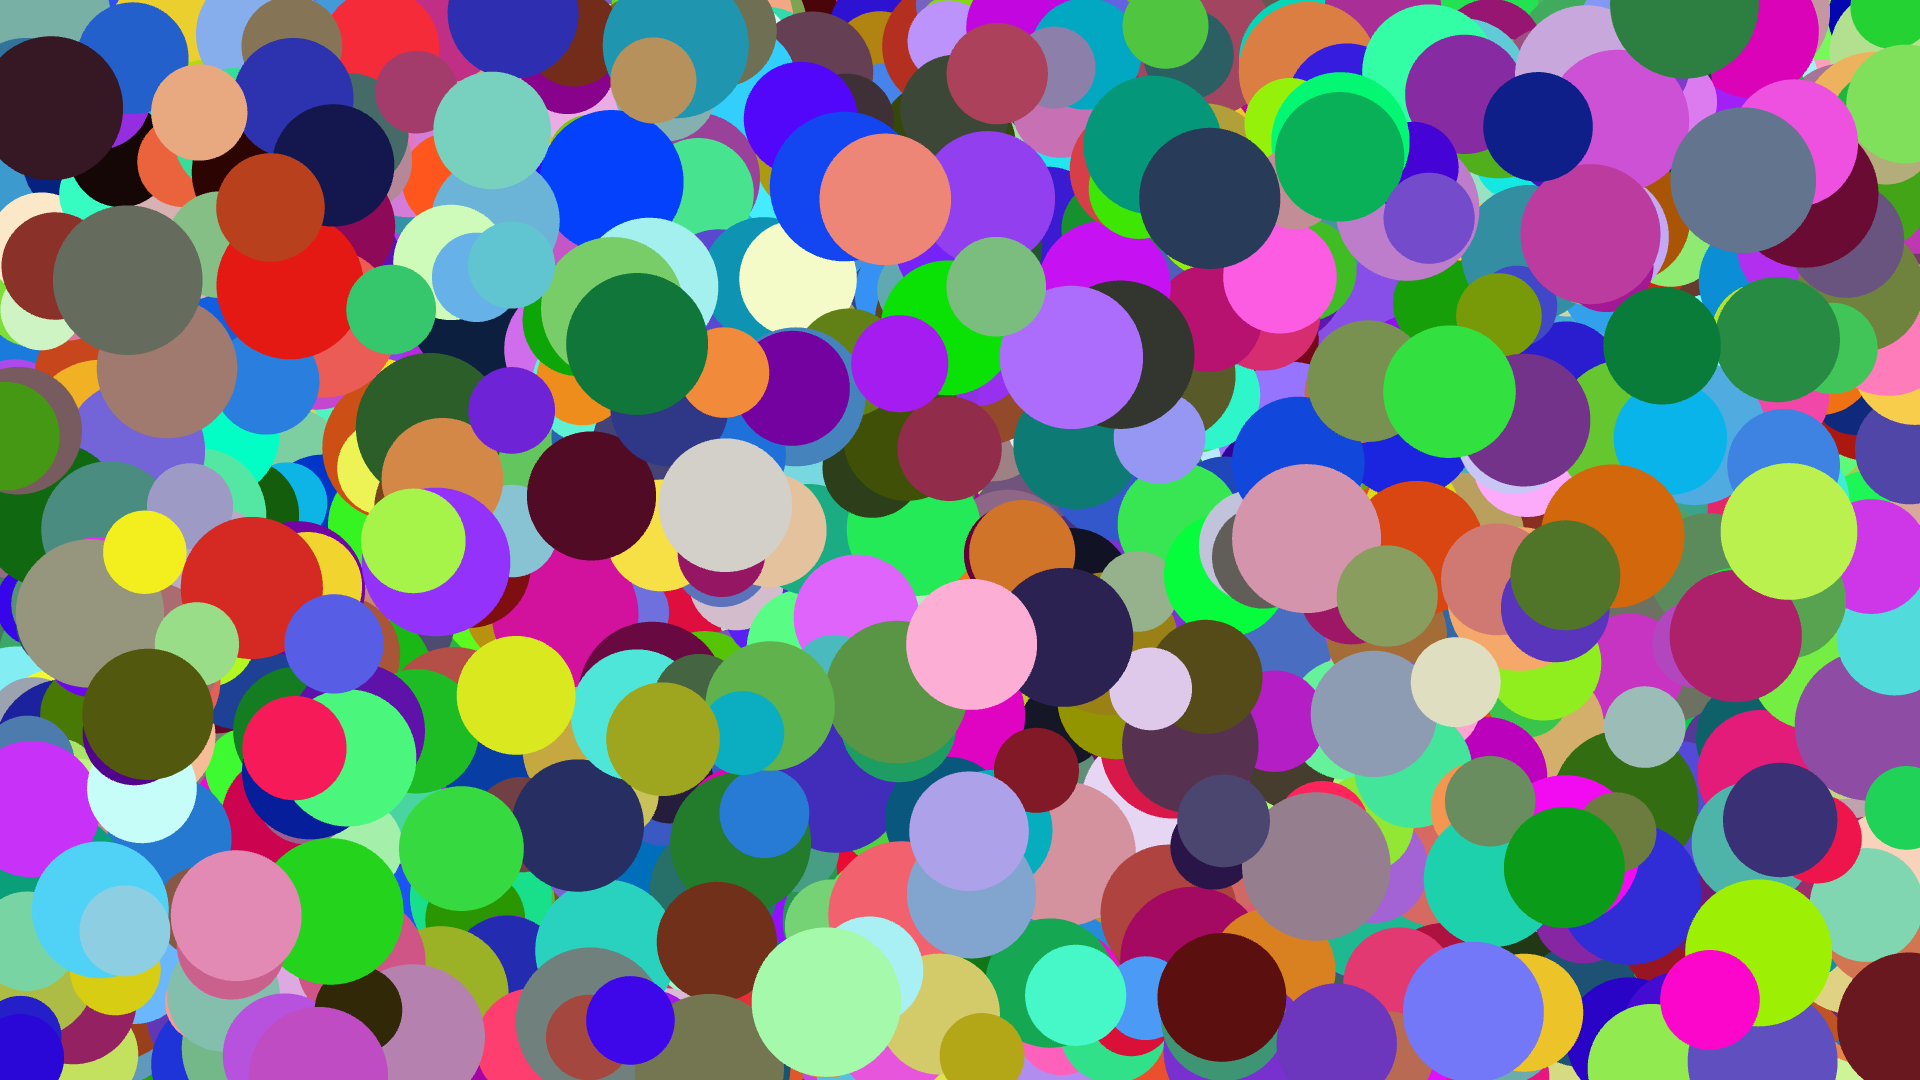

image_1 saved
image_2 start save


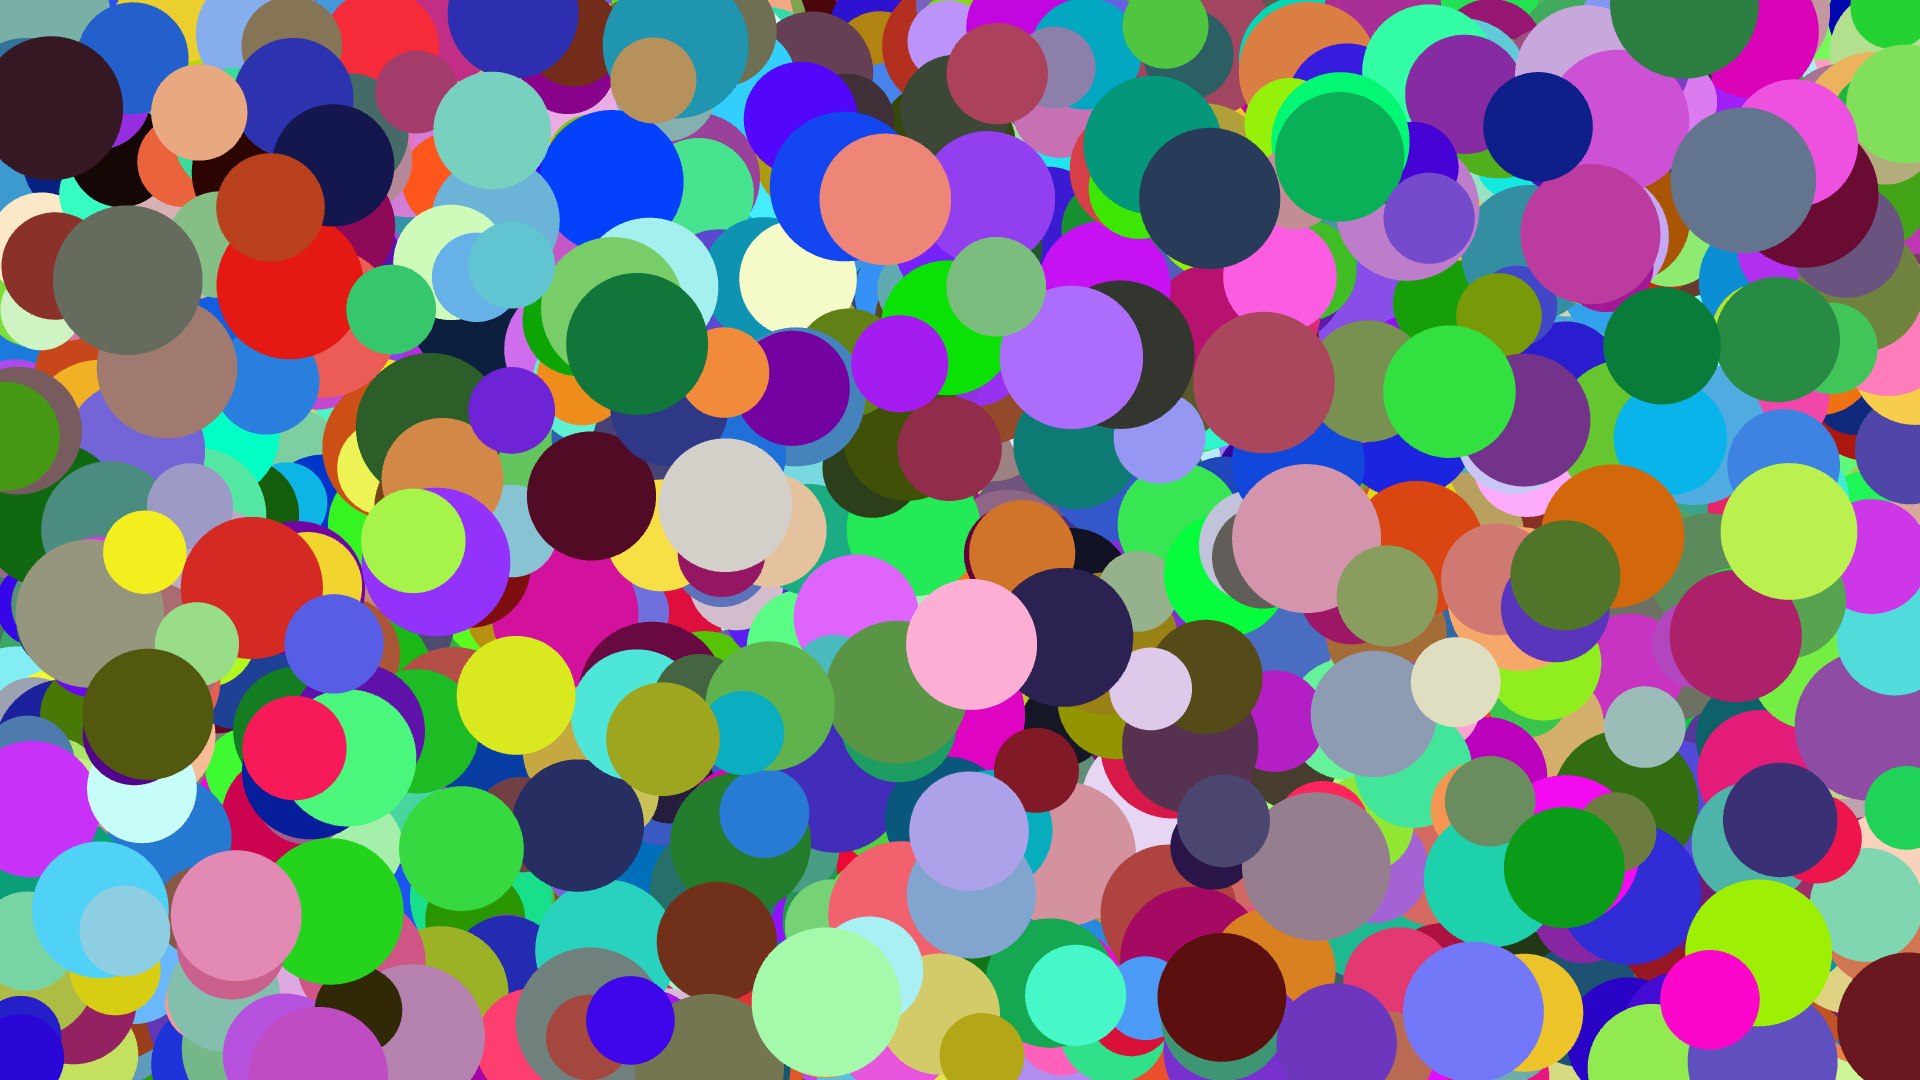

image_2 saved
difference start save
[image_recipe::TextureCache] reusing tiled texture requested_hash=10393962202854585757 cache_key=10393962202854585757


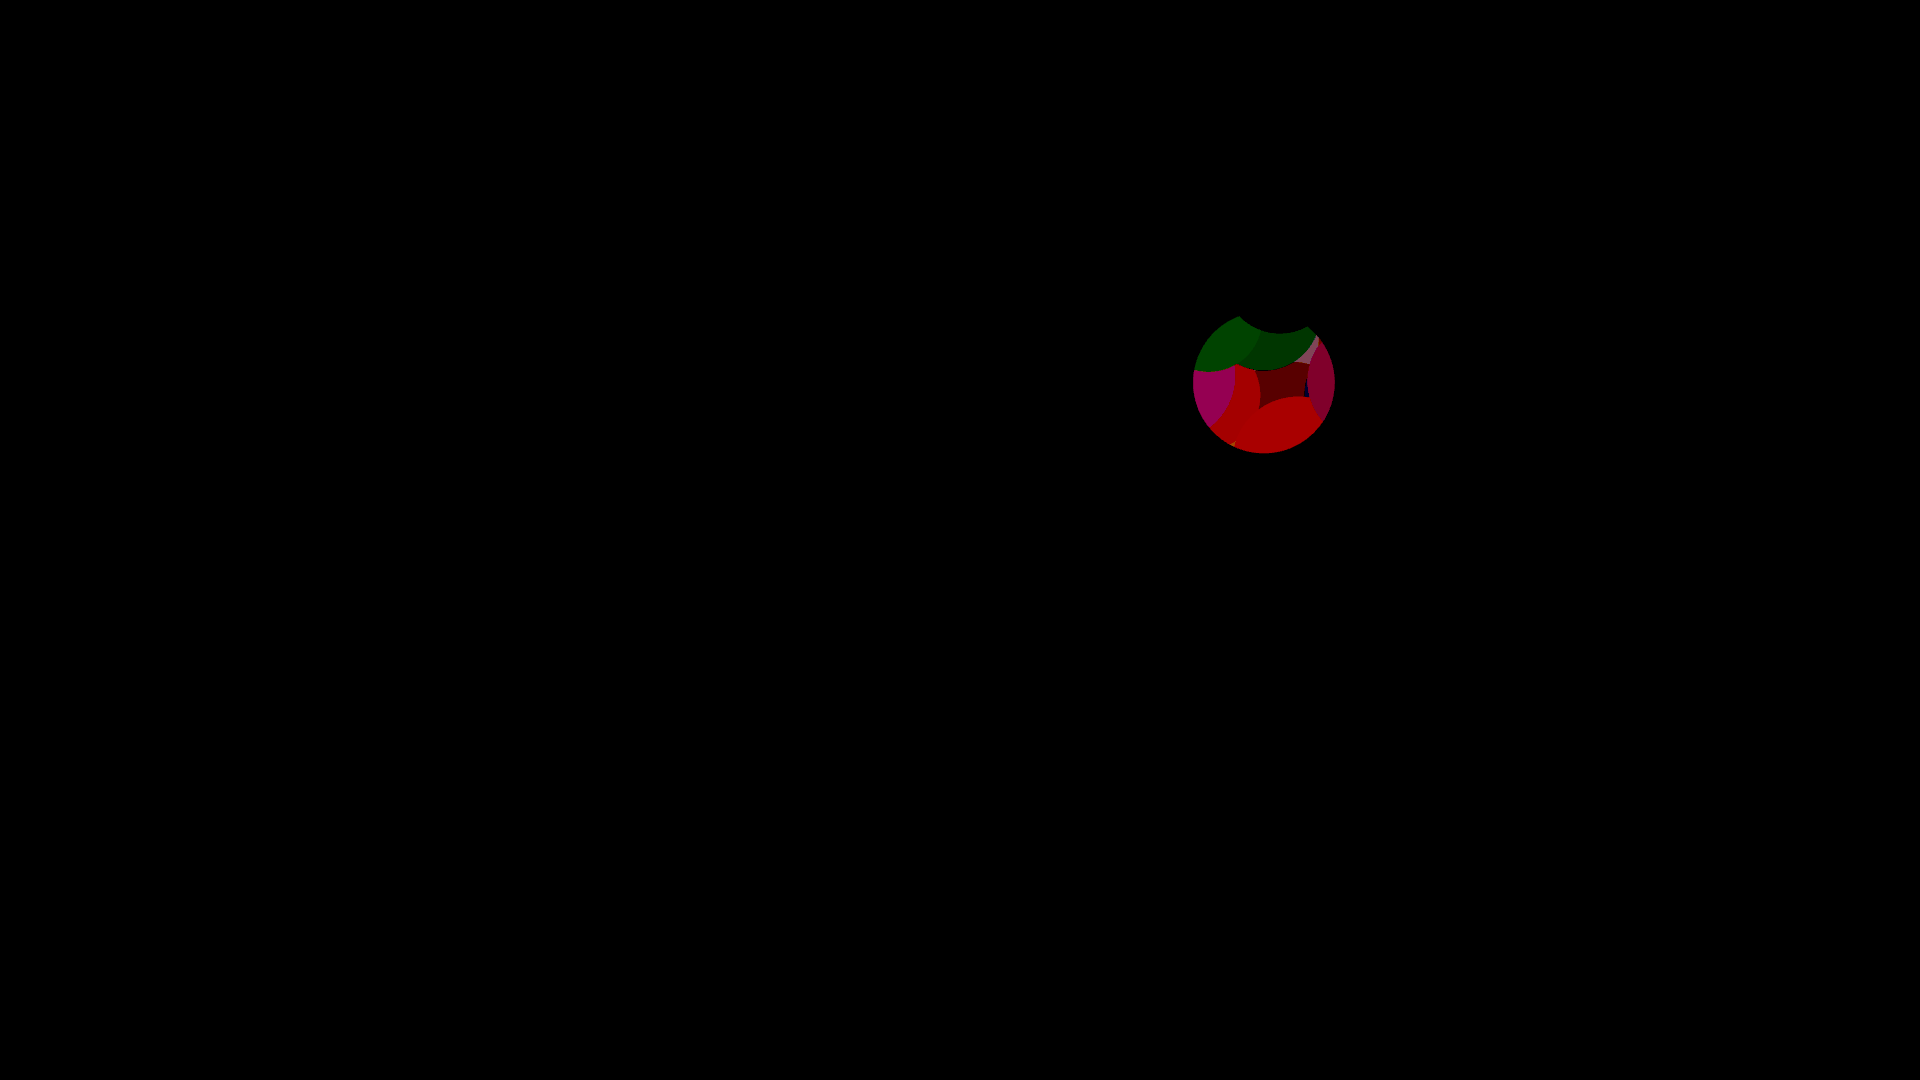

difference saved
absolute_value start save
[image_recipe::TextureCache] reusing tiled texture requested_hash=5704337416392780534 cache_key=5704337416392780534
[image_recipe::TextureCache] reusing tiled texture requested_hash=10393962202854585757 cache_key=10393962202854585757


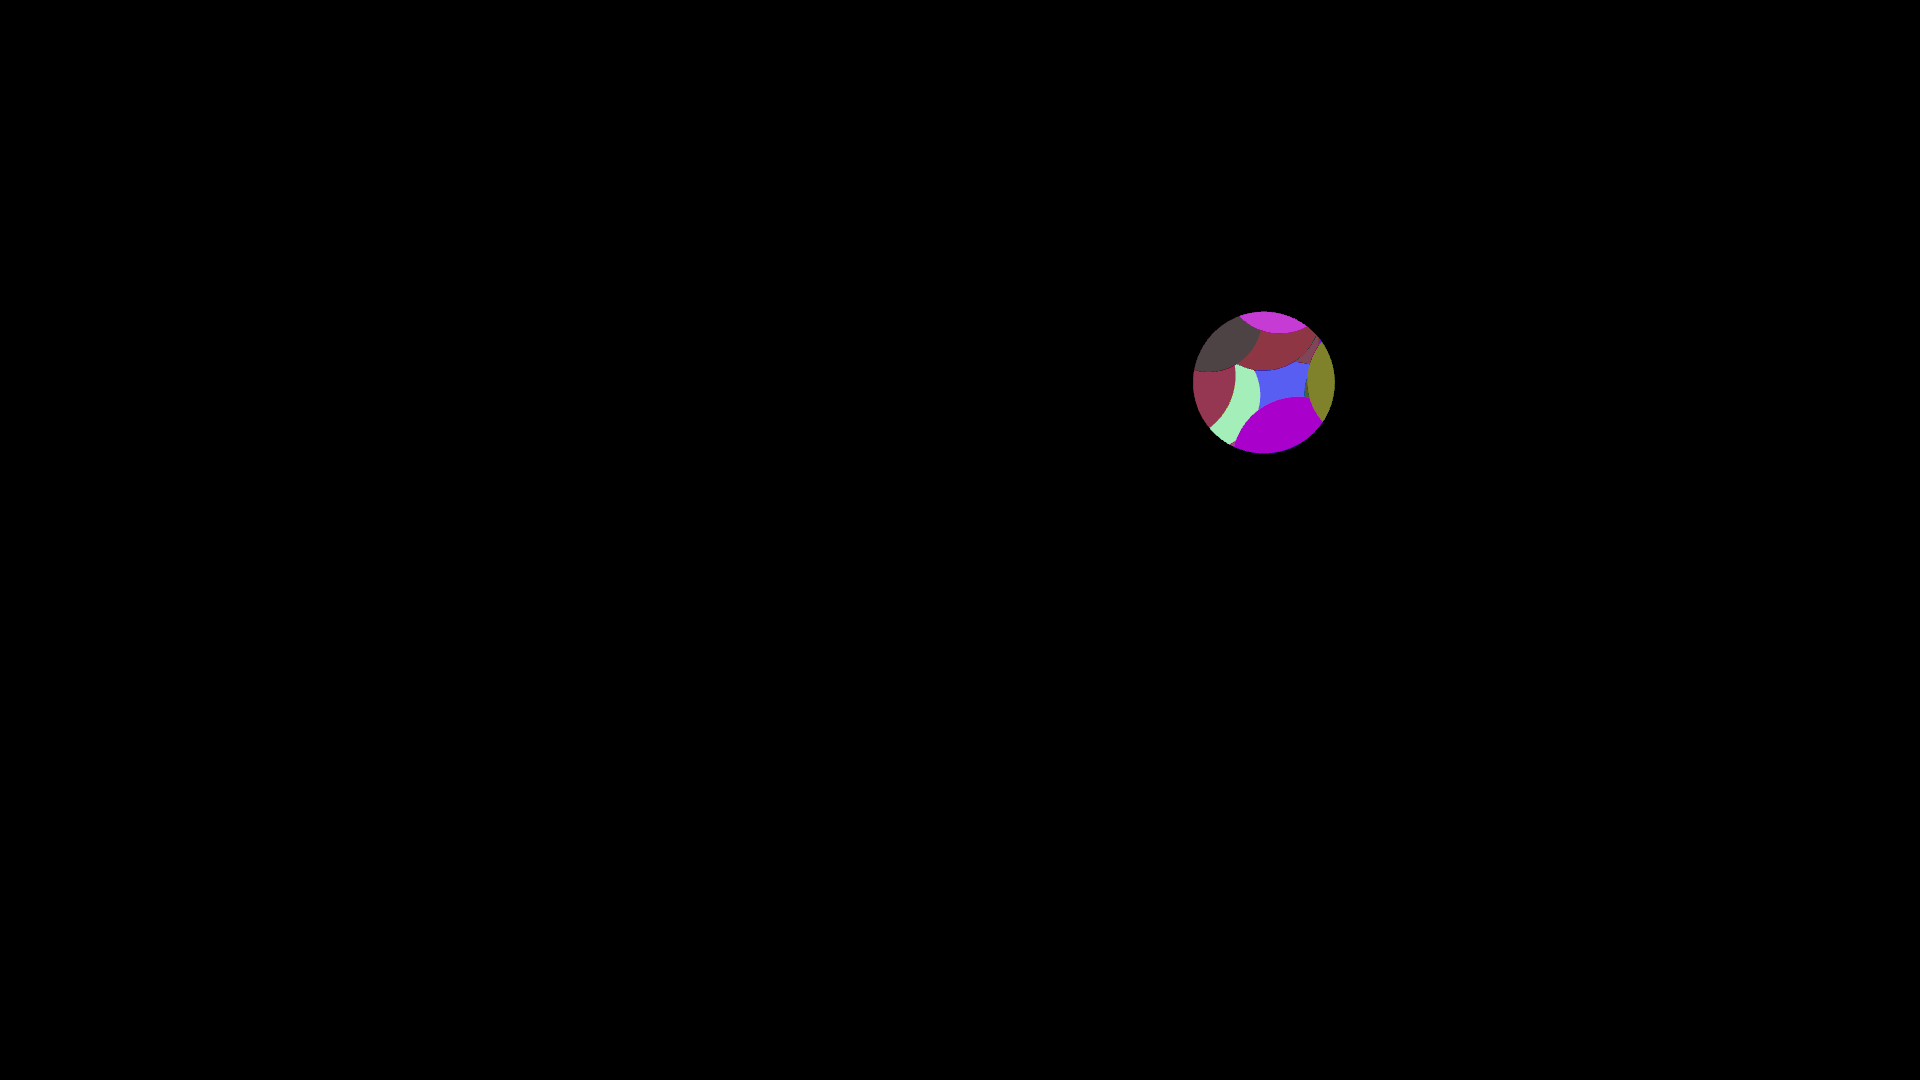

absolute_value saved
threshold start save
[image_recipe::TextureCache] reusing tiled texture requested_hash=5704337416392780534 cache_key=5704337416392780534
[image_recipe::TextureCache] reusing tiled texture requested_hash=10393962202854585757 cache_key=10393962202854585757
new pipeline: color_transformer_shader_rgba16float_compute_12041777719757925520_inarr_false
new pipeline: color_transformer_shader_rgba16float_compute_5800000483768086658_inarr_false


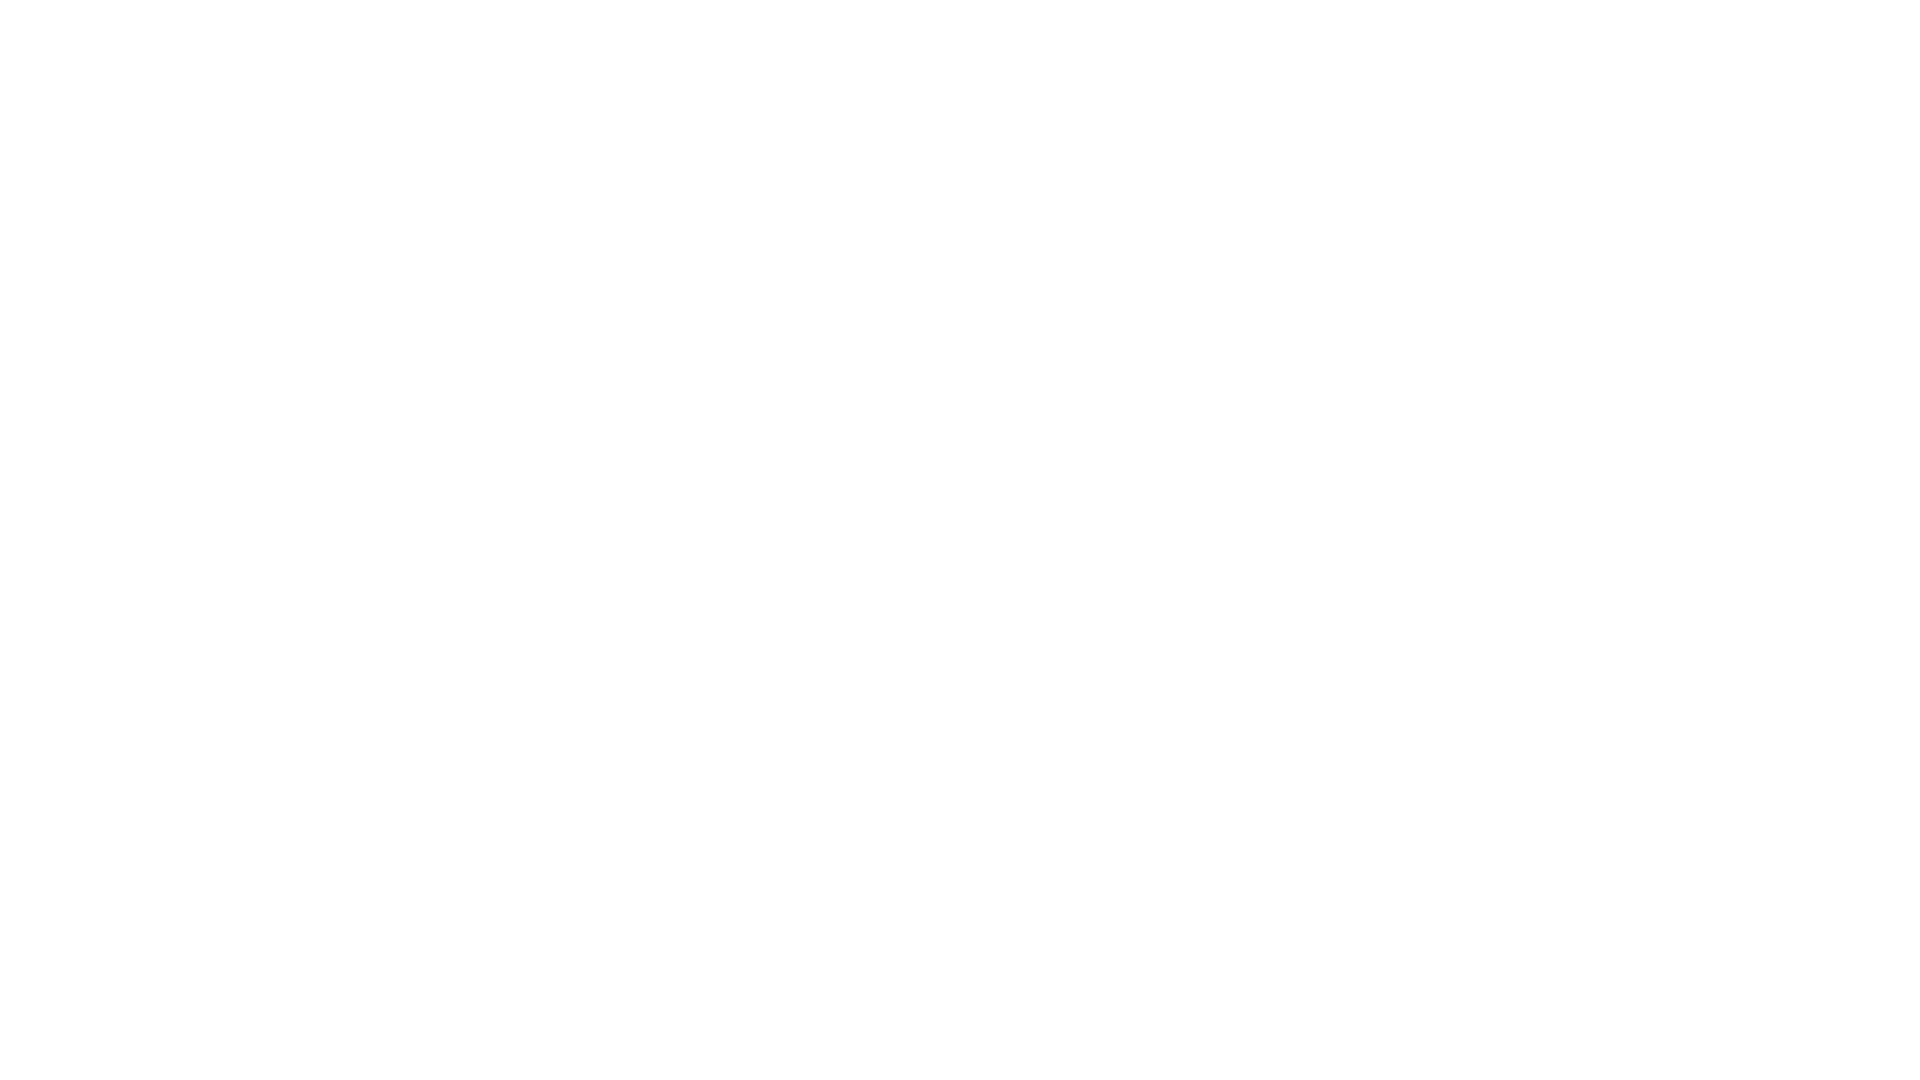

threshold saved
found start save
[image_recipe::TextureCache] reusing tiled texture requested_hash=10393962202854585757 cache_key=10393962202854585757
[image_recipe::TextureCache] reusing tiled texture requested_hash=5704337416392780534 cache_key=5704337416392780534
new pipeline: color_transformer_shader_rgba16float_compute_273576716640682002_inarr_false


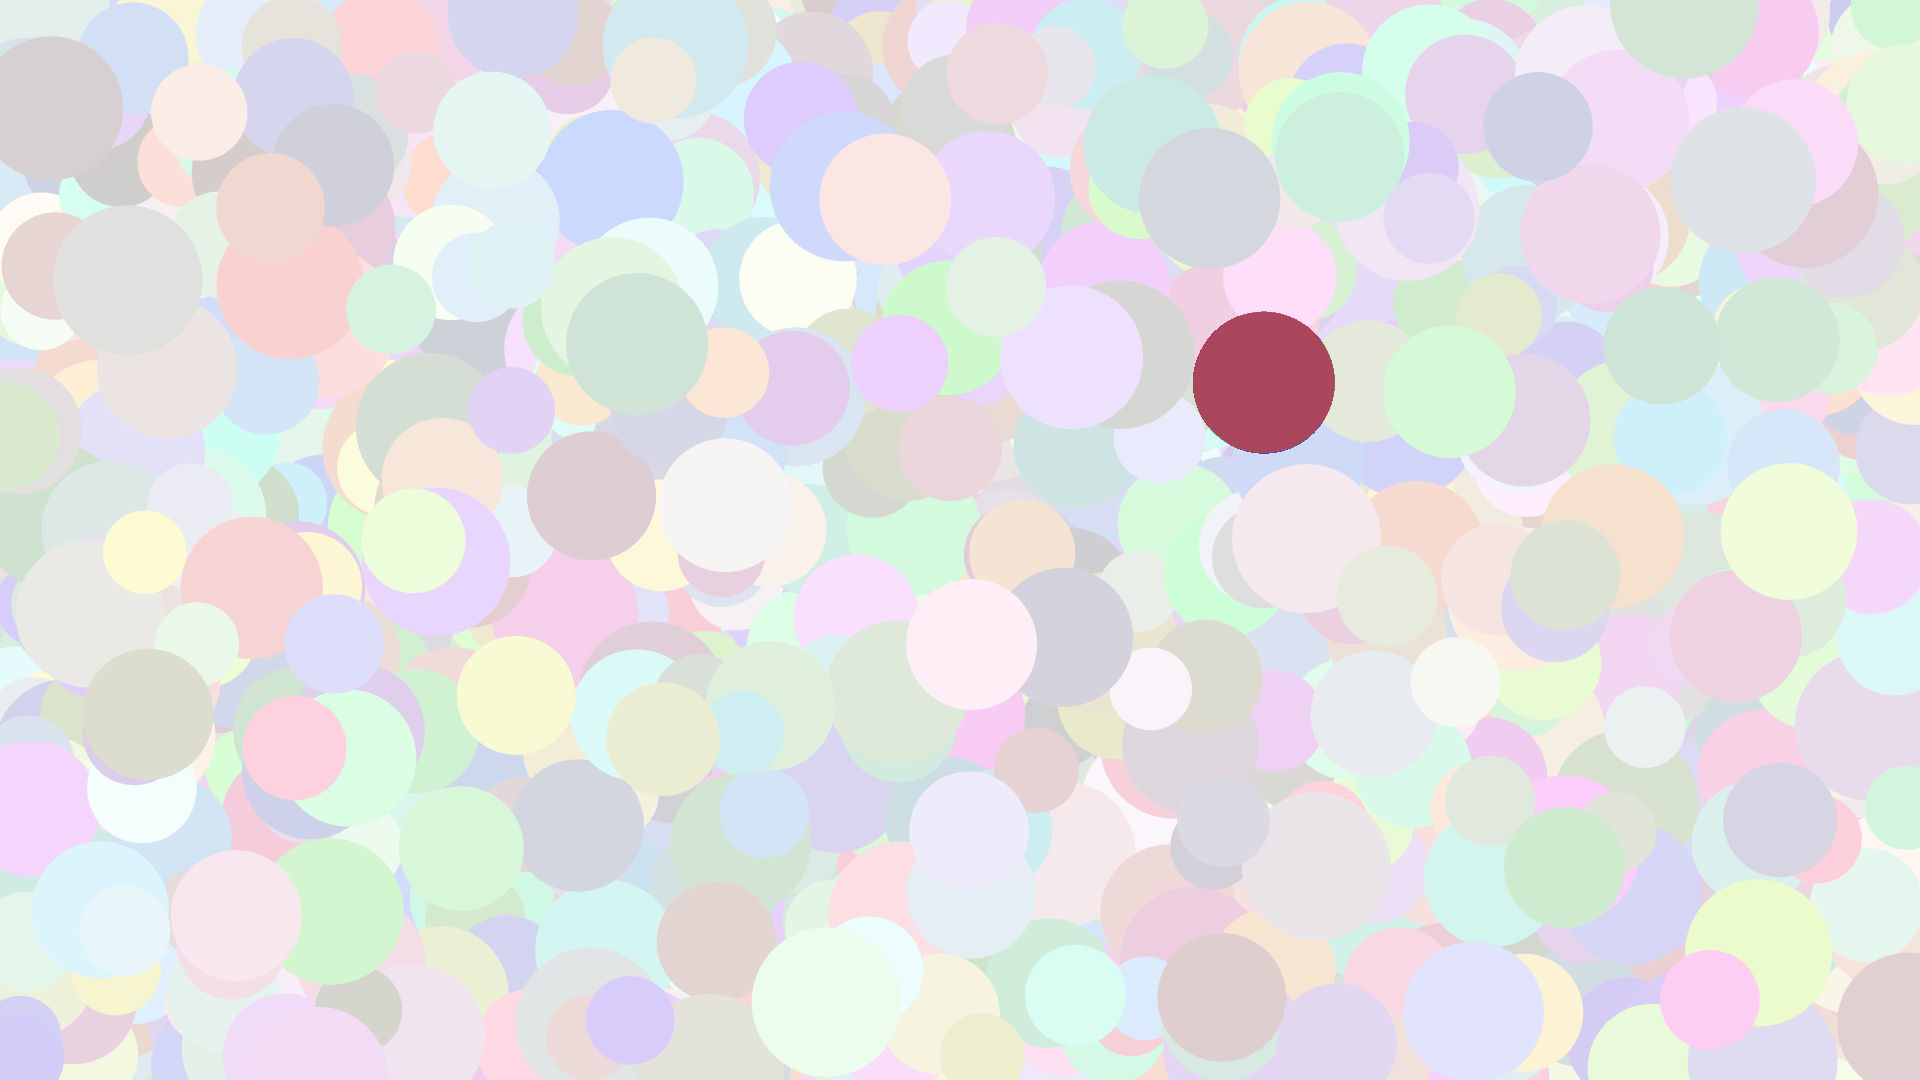

found saved


In [3]:
from IPython.display import Image, display
import random

working_color_profile = brushcue.ColorProfile.srgb()

WIDTH = 1920
HEIGHT = 1080

def save_image(composition: brushcue.Composition, name: str):
    print(f"{name} start save")
    path = Path(f"{OUTPUT_ROOT}/{name}.png")
    path.parent.mkdir(parents=True, exist_ok=True)
    result = composition.execute(ctx)
    output_bytes = result.to_image_bytes(ctx)
    with open(path, "wb") as f:
        f.write(output_bytes)
    display(Image(path))
    print(f"{name} saved")

def generate_base_image_painter(iterations: int) -> brushcue.Composition:
    rng = random.Random(200)
    painter = brushcue.Painter.new()
    painter = painter.add_rectangle_with_render_style(
        brushcue.Point2f.from_components(WIDTH / 2, HEIGHT / 2),
        brushcue.Vector2f.from_components(WIDTH, HEIGHT),
        0,
        brushcue.RenderStyle.fill_only(brushcue.Fill.solid(
            brushcue.ProfiledColor.from_rgba_srgb(
                brushcue.RGBAColor.from_components(0, 0, 0, 1)
            )
        )),
                    brushcue.Transform2.identity().to_list()
    )
    for idx in range(iterations):
        x_coordinate = rng.uniform(0, WIDTH)
        y_coordinate = rng.uniform(0, HEIGHT)

        r = rng.uniform(0, 1)
        g = rng.uniform(0, 1)
        b = rng.uniform(0, 1)

        radius = rng.uniform(80, 150)

        render_style = brushcue.RenderStyle.fill_only(brushcue.Fill.solid(
            brushcue.ProfiledColor.from_rgba_srgb(
                brushcue.RGBAColor.from_components(r, g, b, 1)
            )
        ))

        painter = painter.add_ellipse_with_render_style(
            brushcue.Point2f.from_components(x_coordinate, y_coordinate),
            brushcue.Vector2f.from_components(radius, radius),
            0,
            render_style,
            brushcue.Transform2.identity().to_list()
        )

    composition = brushcue.Composition.painter(painter)
    composition = composition.crop( brushcue.Bounds2f.from_x_y_width_height(0, 0, WIDTH, HEIGHT))
    return composition

image_1 = generate_base_image_painter(2999)
save_image(image_1, "image_1")
image_2 = generate_base_image_painter(3000)
save_image(image_2, "image_2")
difference = image_2.blend_subtract( image_1, brushcue.Transform2.identity())
save_image(difference, "difference")
absolute_value = difference.absolute_value()
save_image(absolute_value, "absolute_value")
threshold = absolute_value.lightness_threshold( 0.001)
save_image(threshold, "threshold")
thresholded_with_min_alpha = threshold.color_transformer_shader(
    "if (input.a < 0.01) { return vec4<f32>(input.rgb, 0.2); } else { return input; }",
    "",
    threshold.color_representation(),
    threshold.color_representation(),
    brushcue.Dictionary.create()
)
blended_over = thresholded_with_min_alpha.blend_stencil( image_2, brushcue.Transform2.identity())
save_image(blended_over, "found")
